# 539 — Alex viable-peer congestion model

**Source:** Alexander Gates (UVA School of Data Science).  
**Companion doc (LaTeX-friendly):** `sports/documents/Alex_model.md`

## Main idea

Systems that concentrate high-performing individuals generate **endogenous congestion** in evaluative comparisons, producing **diminishing and eventually negative marginal returns** to elite affiliation.

Congestion must alter **evaluation and selection** — not merely “more good people nearby.”

In [2]:
##### EDIT BLANK ###### DISCARD
# session: 2026-05-18 — bootstrap 539 Alex model notebook


## Simulation — `simulate_viable_peer_congestion`

Pipeline:

1. Latent ability $a_i \sim \mathrm{Beta}(2,2)$
2. Assortative sort into teams (parameter `assortativity`)
3. Team mean $\bar{a}_t$
4. Viability $v_i = \sigma\big(\gamma(a_i - \theta_v)\big)$ (logistic)
5. Peer congestion $C_{i,t}$ = LOO mean viability on team (Option B below)
6. Eval score $S_i = a_i - \lambda C_{i,t} + \varepsilon_i$
7. Success = top decile of $S_i$ globally

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit


def simulate_viable_peer_congestion(
    N=40_000,
    team_size=20,
    assortativity=0.85,
    noise_sd=0.15,
    lambda_=0.45,
    viability_threshold=0.65,
    viability_sharpness=18,
    seed=1,
):
    """Alex proof-of-concept: viable-peer congestion depresses eval scores."""
    rng = np.random.default_rng(seed)

    # 1. Latent individual ability
    ability = rng.beta(2, 2, size=N)

    # 2. Assortative sorting into teams
    sorting_score = assortativity * ability + (1 - assortativity) * rng.normal(size=N)
    order = np.argsort(sorting_score)
    n_teams = N // team_size

    df = pd.DataFrame(
        {
            "person": order,
            "ability": ability[order],
            "team": np.repeat(np.arange(n_teams), team_size),
        }
    )

    # 3. Team quality
    df["team_mean"] = df.groupby("team")["ability"].transform("mean")

    # 4. Individual viability (smooth threshold in ability)
    df["viability"] = expit(viability_sharpness * (df["ability"] - viability_threshold))

    # 5. Team congestion: density of viable peers
    # Option A (include self): df["team_congestion"] = df.groupby("team")["viability"].transform("mean")
    # Option B (exclude self) — conceptually cleaner:
    team_viability_sum = df.groupby("team")["viability"].transform("sum")
    df["peer_congestion"] = (team_viability_sum - df["viability"]) / (team_size - 1)

    # 6. Evaluation score
    df["eval_score"] = (
        df["ability"] - lambda_ * df["peer_congestion"] + rng.normal(0, noise_sd, size=len(df))
    )

    # 7. Global selection threshold (top 10%)
    threshold = np.quantile(df["eval_score"], 0.90)
    df["success"] = df["eval_score"] >= threshold

    return df

,team_mean,success_rate,mean_ability,peer_congestion,eval_score,viability
0,0.147140,0.000000,0.147140,0.004925,0.144825,0.004925
1,0.198145,0.002500,0.198145,0.008854,0.194419,0.008854
2,0.234761,0.008750,0.234761,0.013455,0.228606,0.013455
3,0.267094,0.016875,0.267094,0.019236,0.256736,0.019236
4,0.300285,0.025000,0.300285,0.027080,0.285130,0.027080
5,0.330361,0.040625,0.330361,0.036725,0.313067,0.036725
6,0.352420,0.045625,0.352420,0.044178,0.328584,0.044178
7,0.375486,0.059375,0.375486,0.053513,0.347593,0.053513
8,0.399700,0.081250,0.399700,0.069149,0.363521,0.069149
9,0.427035,0.090000,0.427035,0.084274,0.376640,0.084274


N=40,000  success rate=0.100


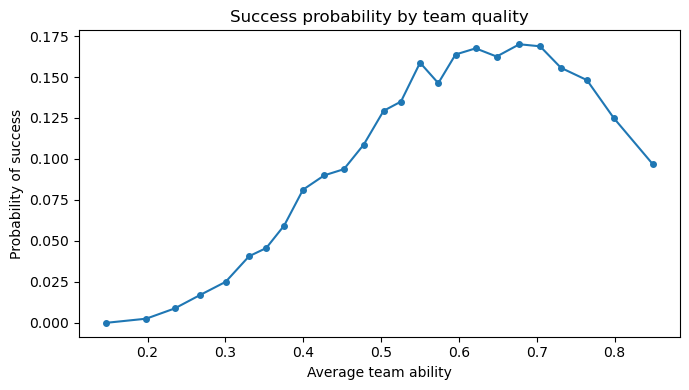

In [4]:
df = simulate_viable_peer_congestion(
    assortativity=0.88,
    noise_sd=0.12,
    lambda_=0.55,
    viability_threshold=0.72,
    viability_sharpness=10,
    seed=1,
)

curve = (
    df.groupby(pd.qcut(df["team_mean"], 25, duplicates="drop"))
    .agg(
        team_mean=("team_mean", "mean"),
        success_rate=("success", "mean"),
        mean_ability=("ability", "mean"),
        peer_congestion=("peer_congestion", "mean"),
        eval_score=("eval_score", "mean"),
        viability=("viability", "mean"),
    )
    .reset_index(drop=True)
)

display(curve.head(10))
print(f"N={len(df):,}  success rate={df['success'].mean():.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve["team_mean"], curve["success_rate"], marker="o", ms=4)
ax.set_xlabel("Average team ability")
ax.set_ylabel("Probability of success")
ax.set_title("Success probability by team quality")
fig.tight_layout()
plt.show()

## Mechanisms (several; not mutually exclusive)

See `Alex_model.md` for full LaTeX. Summary:

1. **Comparative evaluation** — $\text{signal}_i = a_i - f(\text{local peer quality}) + \epsilon_i$
2. **Attribution dilution** — hard to credit individual success on stacked rosters
3. **Finite attention** — too many plausible candidates → heuristics; hurts near-threshold players
4. **Risk minimization** — substitutability → conservative, prototype-driven picks
5. **Opportunity suppression** — minutes, touches, visibility feed back into distinctiveness
6. **Queueing / timing** — few slots, many qualified → delay or exit

**Framing:** elite environments raise both **capability** and **substitutability**.

## NCAA operationalization

Three objects:

- $a_i$ — own ability (PPM or NBA composite)
- $\bar{a}_t = \frac{1}{n_t}\sum_j a_j$
- $C_{i,t}$ — **viable-peer** congestion, not raw teammate quality

Simple:
$$
C_{i,t} = \frac{1}{n_t - 1} \sum_{j \neq i} \mathbf{1}(a_j > \theta)
$$

Role-specific (stronger):
$$
C_{i,t}^{\text{role}} = \frac{1}{n_t - 1} \sum_{j \neq i} w_{ij}\,\mathbf{1}(a_j > \theta)
$$

Draft model: $P(\text{draft}_i) = f(a_i, \bar{a}_t, C_{i,t})$ with $C_{i,t} < 0$.

Inverted-U: baseline $\sim a_i + \bar{a}_t + \bar{a}_t^2$; add $C_{i,t}$ and quadratic should weaken.

Strongest heterogeneity: downturn in **middle-high** prospects, not superstars or non-prospects.

## Secondary empirical tests

1. **Mediation** — $Y_i \sim a_i + \bar{a}_t + \bar{a}_t^2 + C_{i,t}$; expect $C_{i,t}<0$ and smaller top-end penalty.
2. **Congestion bins** — high $C_{i,t}$ teams show steeper right-side decline in success vs. $\bar{a}_t$.
3. **Assortativity** — $Y_i \sim a_i + \bar{a}_t + \bar{a}_t^2 + A_s \cdot \bar{a}_t^2$ (negative interaction).
4. **Near-threshold interaction** — $Y_i \sim a_i + \bar{a}_t + C_{i,t} + a_i \times C_{i,t}$.
5. **Cohort shock / DiD** — new elite recruits depress incumbent near-threshold success.
6. **Mobility** — leaving congested elite teams can *raise* success odds.

**Paper line:** downturn explained by viable-peer density, near-threshold concentration, assortative systems, partial reversal via mobility.

---

**Alexander Gates**  
Assistant Professor, School of Data Science, University of Virginia  
https://www.alexandergates.net/